In [79]:
import argparse as ap
import datetime as dt
import glob
import multiprocessing
from functools import partial
from zoneinfo import ZoneInfo
import numpy as np
import matplotlib.pyplot as plt

import dill as pk
from sotodlib import core

import latcom.utils.net_utils as nu
from latcom.utils.optical_loading import (
    lf_tubes,
    pwv_interp,
)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
result_path = sorted(glob.glob("../../abscals/results_06262026.pk"))[-1]
with open(result_path, "rb") as f:
    result_dict = pk.load(f)
start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 30, tzinfo=dt.timezone.utc)
ufm = "uv42"
band = "220"
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")

obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

pwv = pwv_interp()

if "ln" in ufm:
    if band == "030":
        ufm_band = 1
    elif band == "040":
        ufm_band = 2
elif "mv" in ufm:
    if band == "090":
        ufm_band = 1
    elif band == "150":
        ufm_band = 2
elif "uv" in ufm:
    if band == "220":
        ufm_band = 1
    elif band == "280":
        ufm_band = 2

In [66]:
obs_list_2 = []
for obs in obs_list:
    if f'ufm_{ufm}' in obs["stream_ids_list"]:
        obs_list_2.append(obs)
        
        

In [63]:
ctx = core.Context("../../ctxs/preprocess_260604.yaml")


In [91]:
for i in range(len(obs_list_2)):
    obs = obs_list_2[i]
    meta = ctx.get_meta(obs["obs_id"], dets={ "dets:stream_id": "ufm_" + str(ufm), "dets:wafer.bandpass": "f" + str(band),},)
    
    wafer_flag = np.array([ufm in cur_ufm for cur_ufm in meta.det_info.stream_id])
    bp = (meta.det_cal.bg % 4) // 2
    
    if ufm_band == 1:
        net_flag = wafer_flag * (bp == 0)
    elif ufm_band == 2:
        net_flag = wafer_flag * (bp == 1)
    
    raw_cal = np.nanmedian(meta.abscal.raw_abscal_rj[net_flag])
    if "noise" in meta.preprocess:
        wnoise = meta.preprocess.noise.white_noise[net_flag]
    elif "noiseT" in meta.preprocess:
        wnoise = meta.preprocess.noiseT.white_noise[net_flag]
    else:
        print(f"Error: no valid noise ken in {meta.preprocess.keys()}")
    
    ndet = len(np.where(wnoise != 0)[0])
    net_mes = 1 / np.sqrt(2) * wnoise * raw_cal
    factor = 1e6

    clean_nets = []
    for net in net_mes:
        if net * factor > 50:
            clean_nets.append(net)
    clean_nets = np.array(clean_nets)
    array_net = np.nansum((clean_nets * factor) ** (-2)) ** (-1 / 2)
    print(array_net, 1 / np.sqrt(2) * np.nanmean(wnoise)*1e6 / np.sqrt(ndet) * raw_cal)
    if array_net < 1 / np.sqrt(2) * np.nanmean(wnoise)*1e6 / np.sqrt(ndet) * raw_cal:
        break

11.328126718312527 10.455531941082176
10.97613129361819 10.281436181262142
12.466157892066668 9.356386341189204
11.152326364704113 10.24946972802471
10.58942046243291 9.918679564823373
9.803384949269509 9.124902086528353
9.603977107283473 9.281830227422157
9.726079592521167 9.48208931555378
9.918465773822458 10.19844098453153


(array([585.,  17.,   4.,   3.,   1.,   1.,   3.,   0.,   1.,   1.]),
 array([ 129.6167295 ,  409.79754673,  689.97836396,  970.15918119,
        1250.33999842, 1530.52081565, 1810.70163289, 2090.88245012,
        2371.06326735, 2651.24408458, 2931.42490181]),
 <BarContainer object of 10 artists>)

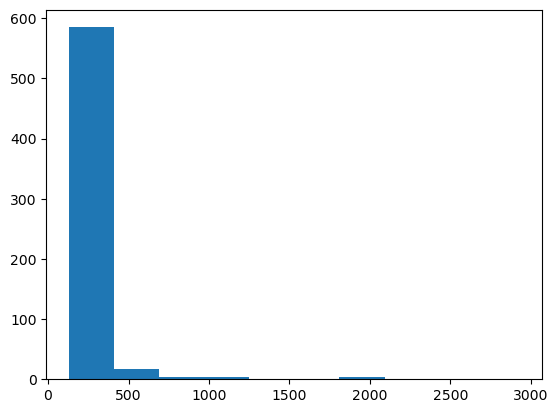

In [93]:
plt.hist(1e6*clean_nets)

In [84]:
 1 / np.sqrt(2) * 1e6*np.nanmean(clean_nets)  / np.sqrt(ndet) * raw_cal

np.float64(12.952914263688783)

In [86]:
np.nansum((clean_nets * 1e6) ** (-2)) ** (-1 / 2)

np.float32(5.2512493)

In [ ]:
clean_neps = []
for nep in wnoise:
    if net * factor > 100:
        clean_nets.append(net)

(array([180.,   1.,   3., 466.,  32.,   0.,   3.,   1.,   0.,   1.]),
 array([  0.        ,  29.21288681,  58.42577362,  87.63865662,
        116.85154724, 146.06443787, 175.27731323, 204.49020386,
        233.70309448, 262.91598511, 292.12887573]),
 <BarContainer object of 10 artists>)

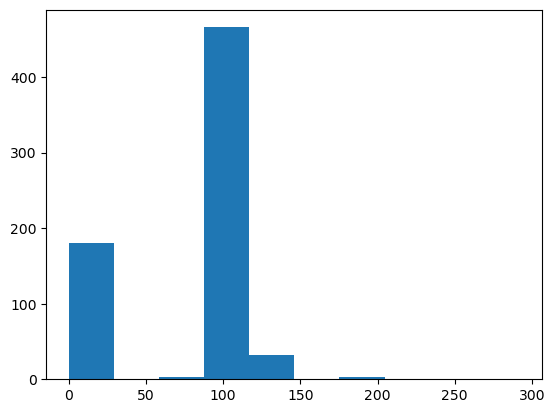

In [90]:
plt.hist(wnoise*1e6)